In [40]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

from google.colab import drive
import warnings

warnings.filterwarnings('ignore')
print('Libraries imported successfully')

Libraries imported successfully


In [41]:
# Google drive connection

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
# Loading preprocessor, data processed, labels and variable names (from Notebook 03)

preprocessor = joblib.load(
    "/content/drive/MyDrive/Credit_Risk_Project/models/preprocessor.pkl"
)

X_train = np.load(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/X_train_processed.npy"
)

X_test = np.load(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/X_test_processed.npy"
)

y_train = pd.read_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/y_test.csv"
).squeeze()

feature_names = pd.read_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/feature_names.csv"
)

**MODEL EVALUATION UTILITY**

In [43]:
# Calculate metrics function

def calculate_metrics(model, model_name, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results = pd.DataFrame({

        "Model":[model_name],

        "Accuracy":[accuracy_score(y_test,y_pred)],

        "Precision":[precision_score(y_test,y_pred)],

        "Recall":[recall_score(y_test,y_pred)],

        "F1 Score":[f1_score(y_test,y_pred)],

        "ROC-AUC":[roc_auc_score(y_test,y_prob)]

    })

    return results

In [44]:
# Classification report function

def print_classification_report(
    model,
    X_test,
    y_test
):

    y_pred = model.predict(X_test)

    print(classification_report(
        y_test,
        y_pred
    ))

In [45]:
# Confusion matrix function

def plot_confusion_matrix(
    model,
    X_test,
    y_test,
    model_name
):

    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(

        y_test,

        y_pred

    )

    plt.title(model_name)
    plt.show()

**Hyperparameter Tuning for KNN**

In [46]:
# Function to train various values of k

def evaluate_knn_models(
    k_values,
    X_train,
    y_train,
    X_test,
    y_test
):

    results = []

    for k in k_values:

        model = KNeighborsClassifier(
            n_neighbors=k
        )

        model.fit(
            X_train,
            y_train
        )

        metrics = calculate_metrics(
            model,
            f"KNN (k={k})",
            X_test,
            y_test
        )

        results.append(metrics)

    comparison = pd.concat(
        results,
        ignore_index=True
    )

    return comparison

**Hyperparameter Tuning for Decision Tree (DT)**

In [47]:
def evaluate_decision_tree_depths(

    depths,
    X_train,
    y_train,
    X_test,
    y_test

):

    results = []

    for depth in depths:

        model = DecisionTreeClassifier(

            max_depth=depth,
            random_state=42

        )

        model.fit(

            X_train,
            y_train

        )

        metrics = calculate_metrics(

            model,
            f"Tree (depth={depth})",
            X_test,
            y_test

        )

        results.append(metrics)

    comparison = pd.concat(

        results,
        ignore_index=True

    )

    return comparison

In [48]:
# Building baseline model (dummy classifier)
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

In [49]:
# Training dummy classifier
dummy_model.fit(
    X_train,
    y_train
)

DummyClassifier(strategy='most_frequent')

In [50]:
# Predict dummy classifier
y_dummy_pred = dummy_model.predict(
    X_test
)

In [51]:
# Accuracy
dummy_accuracy = accuracy_score(
    y_test,
    y_dummy_pred
)

print(dummy_accuracy)

0.8838652829449775


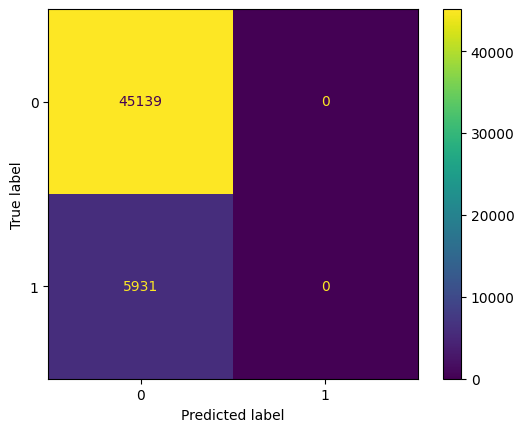

In [52]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_dummy_pred
)

**LOGISTIC REGRESSION MODEL**

In [53]:
# Building LR Model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [54]:
# Training LR model
logistic_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [55]:
# Pedictions
# Class prediction
y_pred = logistic_model.predict(X_test)

In [56]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [57]:
# Probability
y_prob = logistic_model.predict_proba(X_test)

In [58]:
y_prob

array([[0.96979399, 0.03020601],
       [0.97958846, 0.02041154],
       [0.92397763, 0.07602237],
       ...,
       [0.90755697, 0.09244303],
       [0.92682588, 0.07317412],
       [0.96357232, 0.03642768]])

In [59]:
# Handly accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8852


In [60]:
# Handly precision
precision = precision_score(
    y_test,
    y_pred
)

print(f"Precision: {precision:.4f}")

Precision: 0.6054


In [61]:
# Handly recall
recall = recall_score(
    y_test,
    y_pred
)

print(f"Recall: {recall:.4f}")

Recall: 0.0339


In [62]:
# Handly f1-score
f1 = f1_score(
    y_test,
    y_pred
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.0642


In [63]:
# Handly roc-auc
roc_auc = roc_auc_score(
    y_test,
    y_prob[:, 1]
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.7531


In [64]:
# Showing all metrics together
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics

,Metric,Value
0,Accuracy,0.885236
1,Precision,0.605422
2,Recall,0.033890
3,F1 Score,0.064186
4,ROC-AUC,0.753116


In [65]:
# Classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070



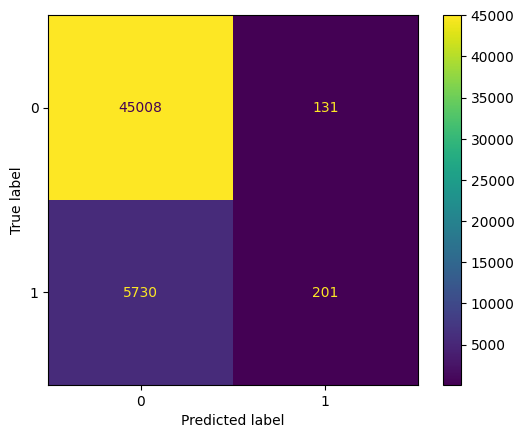

In [66]:
# Confusion matrix LR model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [67]:
# Improving Logistic Regression with balanced
# Building LR model
logistic_balanced = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

In [68]:
# Training LR model
logistic_balanced.fit(
    X_train,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [69]:
# Predictions of LR model
y_pred_balanced = logistic_balanced.predict(X_test)

y_prob_balanced = logistic_balanced.predict_proba(X_test)

In [70]:
# Handly accuracy LR model improved
accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6763


In [71]:
# Handly precision LR model improved
precision = precision_score(
    y_test,
    y_pred_balanced
)

print(f"Precision: {precision:.4f}")

Precision: 0.2195


In [72]:
# Handly recall LR model improved
recall = recall_score(
    y_test,
    y_pred_balanced
)

print(f"Recall: {recall:.4f}")

Recall: 0.6994


In [73]:
# Handly f1-score LR model improved
f1 = f1_score(
    y_test,
    y_pred_balanced
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.3342


In [74]:
# Handly roc-auc LR model improved
roc_auc = roc_auc_score(
    y_test,
    y_prob_balanced[:, 1]
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.7532


In [75]:
# Showing all metrics together LR model improved
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics

,Metric,Value
0,Accuracy,0.676346
1,Precision,0.219541
2,Recall,0.699376
3,F1 Score,0.334179
4,ROC-AUC,0.753179


In [76]:
# Classification report LR model improved
print(
    classification_report(
        y_test,
        y_pred_balanced
    )
)

              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



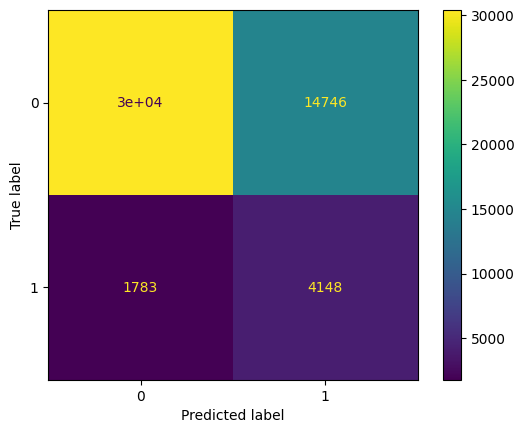

In [77]:
# Confusion matrix LR model improved
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_balanced
)

In [78]:
# Evaluate model function
"""
def evaluate_model(model, model_name, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results = pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_test, y_pred)],
        "Precision": [precision_score(y_test, y_pred)],
        "Recall": [recall_score(y_test, y_pred)],
        "F1 Score": [f1_score(y_test, y_pred)],
        "ROC-AUC": [roc_auc_score(y_test, y_prob)]
    })

    print(results)

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )

    plt.title(model_name)
    plt.show()

    return results"""

'\ndef evaluate_model(model, model_name, X_test, y_test):\n\n    y_pred = model.predict(X_test)\n    y_prob = model.predict_proba(X_test)[:,1]\n\n    results = pd.DataFrame({\n        "Model": [model_name],\n        "Accuracy": [accuracy_score(y_test, y_pred)],\n        "Precision": [precision_score(y_test, y_pred)],\n        "Recall": [recall_score(y_test, y_pred)],\n        "F1 Score": [f1_score(y_test, y_pred)],\n        "ROC-AUC": [roc_auc_score(y_test, y_prob)]\n    })\n\n    print(results)\n\n    print("\nClassification Report\n")\n\n    print(classification_report(y_test, y_pred))\n\n    ConfusionMatrixDisplay.from_predictions(\n        y_test,\n        y_pred\n    )\n\n    plt.title(model_name)\n    plt.show()\n\n    return results'

In [79]:
# Testing calculate_metrics function with LR model
logistic_results = calculate_metrics(

    logistic_model,
    "Logistic Regression",
    X_test,
    y_test
)

In [80]:
print_classification_report(

    logistic_model,
    X_test,
    y_test
)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070



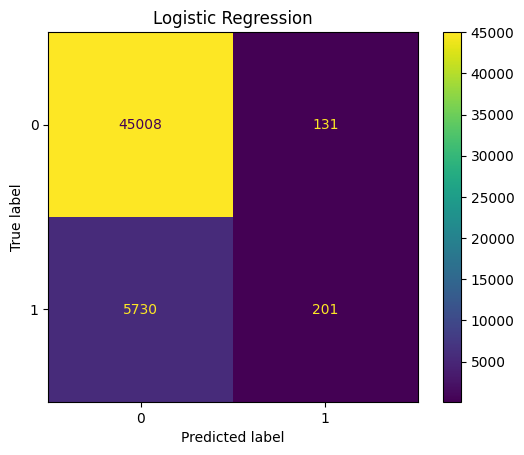

In [81]:
plot_confusion_matrix(

    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"

)

**K-NEAREST NEIGHBORS (KNN)**

In [82]:
# Building KNN model
"""knn_model = KNeighborsClassifier(
    n_neighbors=5
)"""

'knn_model = KNeighborsClassifier(\n    n_neighbors=5\n)'

In [83]:
# Training KNN model
"""knn_model.fit(
    X_train,
    y_train
)"""

'knn_model.fit(\n    X_train,\n    y_train\n)'

In [84]:
# Evaluate model
"""knn_results = calculate_metrics(
    knn_model,
    "KNN (k=5)",
    X_test,
    y_test
)

knn_results"""

'knn_results = calculate_metrics(\n    knn_model,\n    "KNN (k=5)",\n    X_test,\n    y_test\n)\n\nknn_results'

In [85]:
# Classification report and confusion matrix
"""print_classification_report(
    knn_model,
    X_test,
    y_test
)

plot_confusion_matrix(
    knn_model,
    X_test,
    y_test,
    "KNN (k=5)"
)"""

'print_classification_report(\n    knn_model,\n    X_test,\n    y_test\n)\n\nplot_confusion_matrix(\n    knn_model,\n    X_test,\n    y_test,\n    "KNN (k=5)"\n)'

In [86]:
# Testing evaluate_knn_models function
"""k_values = [3, 5, 7, 9, 11, 15]

knn_results = evaluate_knn_models(
    k_values,
    X_train,
    y_train,
    X_test,
    y_test
)

knn_results"""

'k_values = [3, 5, 7, 9, 11, 15]\n\nknn_results = evaluate_knn_models(\n    k_values,\n    X_train,\n    y_train,\n    X_test,\n    y_test\n)\n\nknn_results'

**DECISION TREE**

In [87]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

In [88]:
tree_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [89]:
tree_results = calculate_metrics(
    tree_model,
    "Decision Tree",
    X_test,
    y_test
)

tree_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.801978,0.196076,0.227449,0.2106,0.552458


              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45139
           1       0.20      0.23      0.21      5931

    accuracy                           0.80     51070
   macro avg       0.55      0.55      0.55     51070
weighted avg       0.81      0.80      0.81     51070



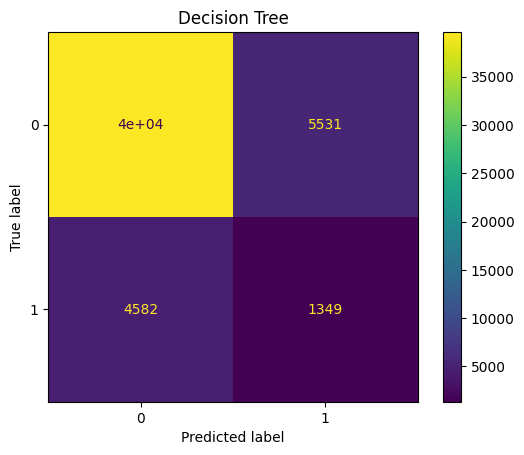

In [90]:
print_classification_report(
    tree_model,
    X_test,
    y_test
)

plot_confusion_matrix(
    tree_model,
    X_test,
    y_test,
    "Decision Tree"
)

In [91]:
# Defining depths
depths = [3,5,7,10,15,None]

In [92]:
# Training for every depth
tree_results = evaluate_decision_tree_depths(

    depths,
    X_train,
    y_train,
    X_test,
    y_test

)

tree_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tree (depth=3),0.883865,0.000000,0.000000,0.000000,0.684295
1,Tree (depth=5),0.884883,0.626214,0.021750,0.042040,0.715950
2,Tree (depth=7),0.885393,0.608939,0.036756,0.069327,0.725115
3,Tree (depth=10),0.881790,0.430809,0.055640,0.098552,0.714972
4,Tree (depth=15),0.858136,0.266026,0.125948,0.170958,0.617821
5,Tree (depth=None),0.801978,0.196076,0.227449,0.210600,0.552458


**RANDOM FOREST**

In [93]:
# Building RF model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [94]:
# Training RF model
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [95]:
# Evaluate RF model
rf_results = calculate_metrics(
    rf_model,
    "Random Forest",
    X_test,
    y_test
)

rf_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.88551,0.627273,0.034901,0.066124,0.737292


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.63      0.03      0.07      5931

    accuracy                           0.89     51070
   macro avg       0.76      0.52      0.50     51070
weighted avg       0.86      0.89      0.84     51070



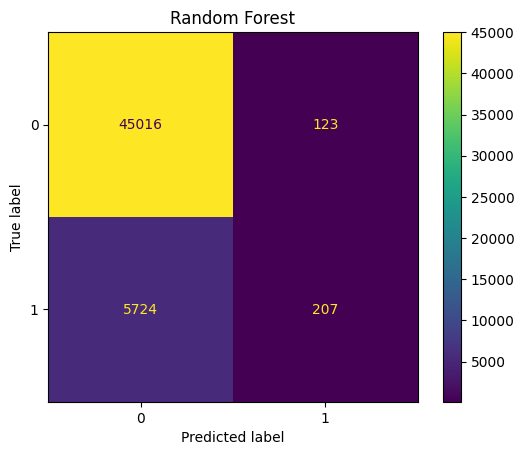

In [96]:
# Classification report and confusion matrix of RF
print_classification_report(
    rf_model,
    X_test,
    y_test
)

plot_confusion_matrix(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

**RANDOM FOREST BALANCED/IMPROVED**

In [97]:
# Building RF model balanced
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

In [98]:
# Training RF model balanced
rf_balanced.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [99]:
# Evaluate RF model balanced
rf_balanced_results = calculate_metrics(
    rf_balanced,
    "Random Forest Balanced",
    X_test,
    y_test
)

rf_balanced_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest Balanced,0.884981,0.679245,0.018209,0.035468,0.735401


In [100]:
# Classification report of RF balanced
print_classification_report(
    rf_balanced,
    X_test,
    y_test
)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.68      0.02      0.04      5931

    accuracy                           0.88     51070
   macro avg       0.78      0.51      0.49     51070
weighted avg       0.86      0.88      0.83     51070



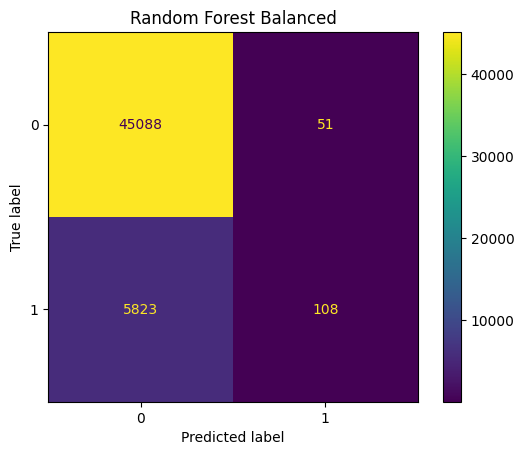

In [101]:
# Confusion Matrix of RF balanced
plot_confusion_matrix(
    rf_balanced,
    X_test,
    y_test,
    "Random Forest Balanced"
)